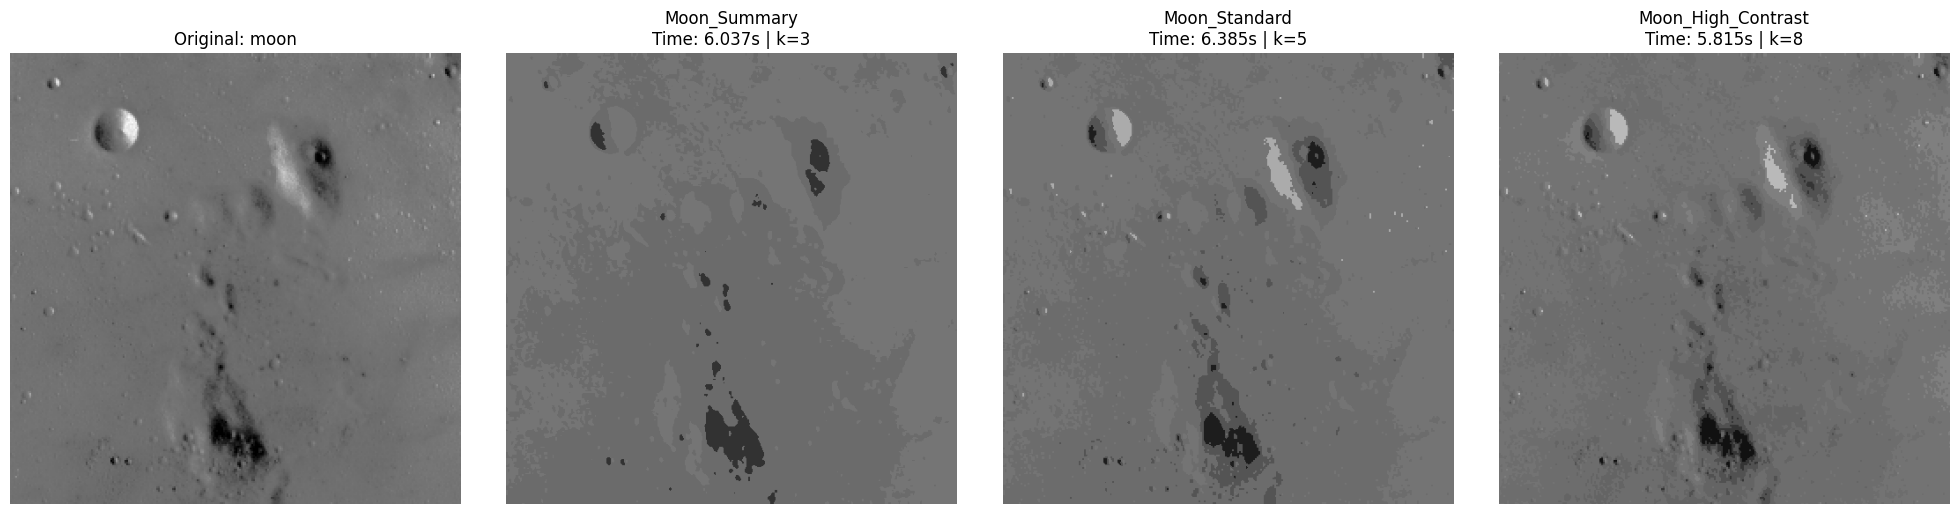

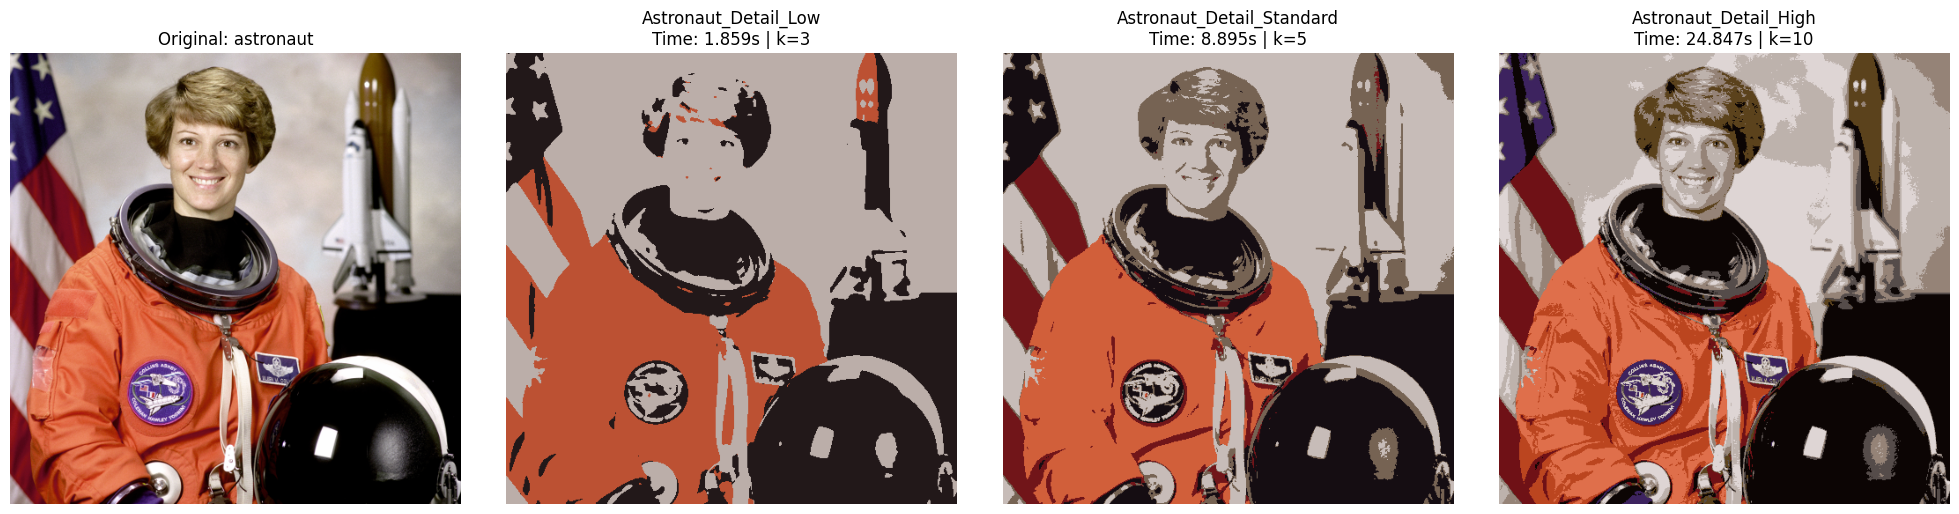

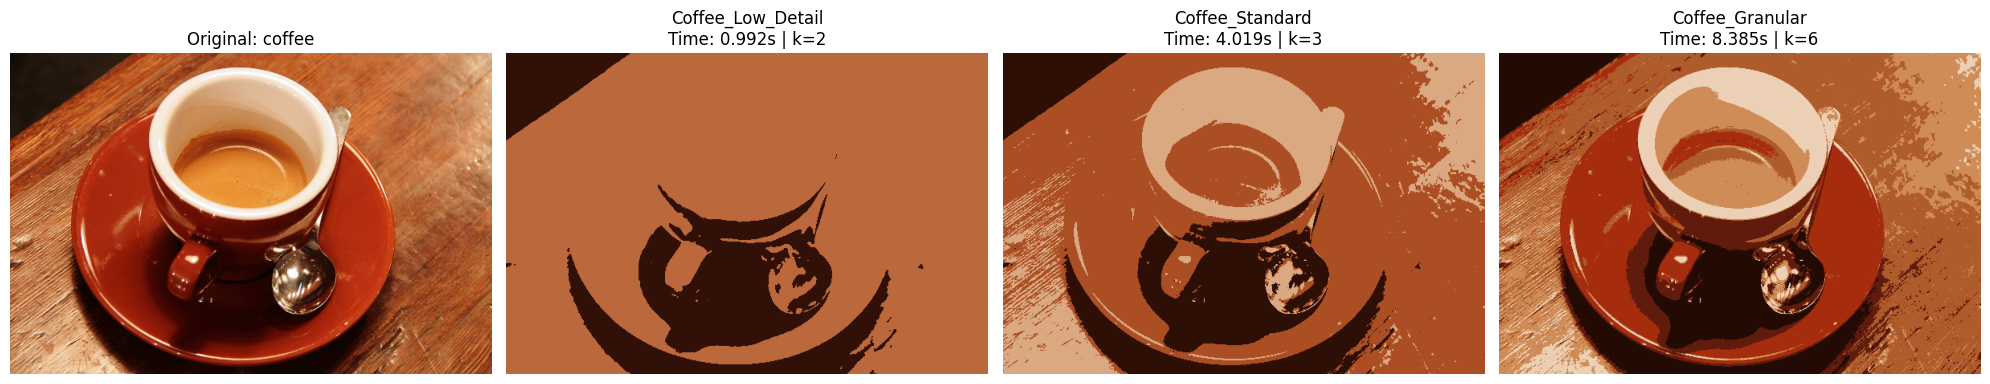

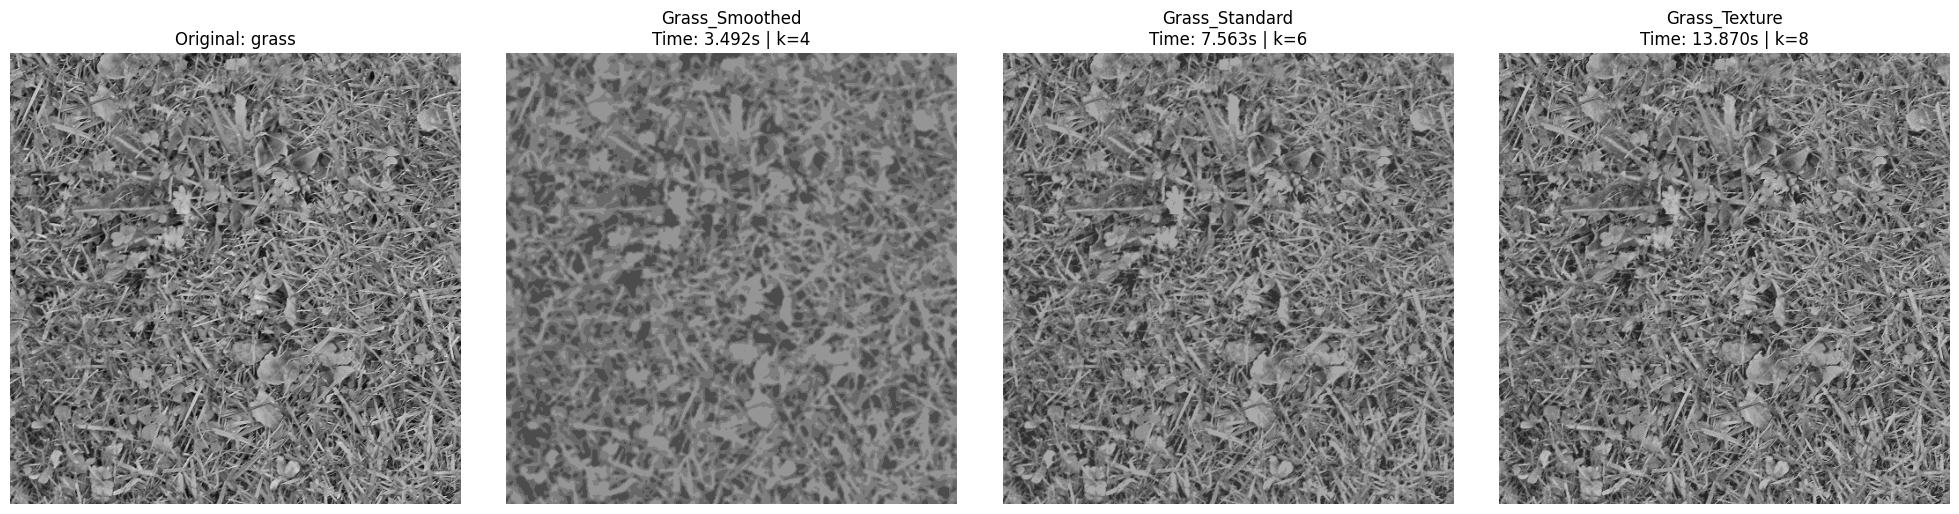

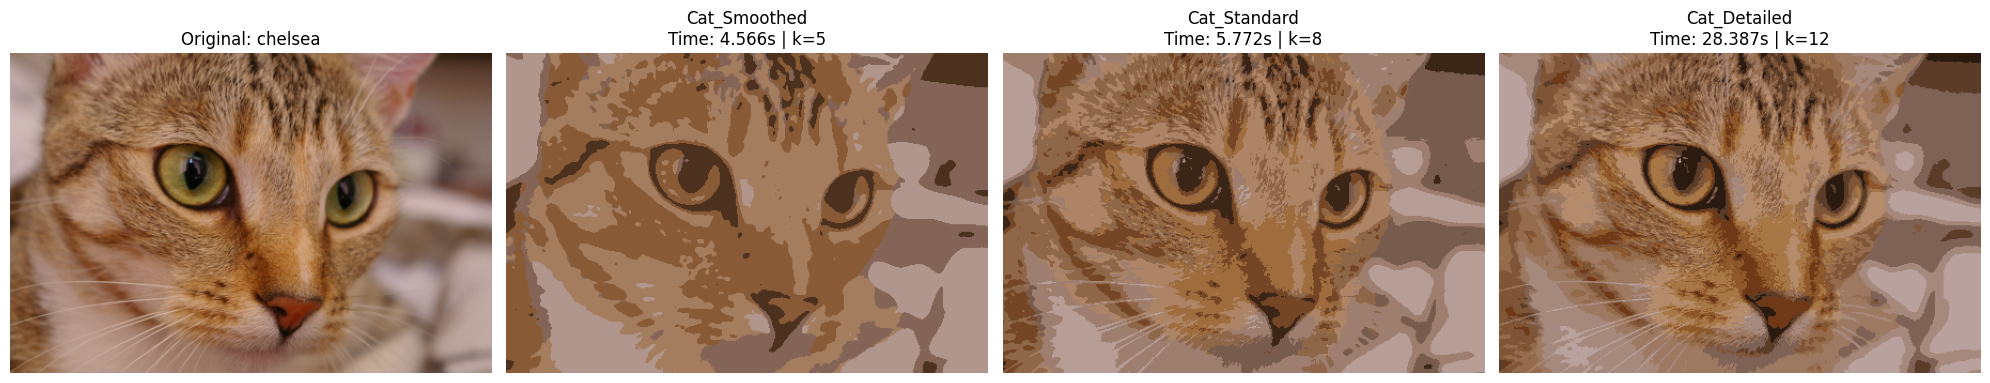

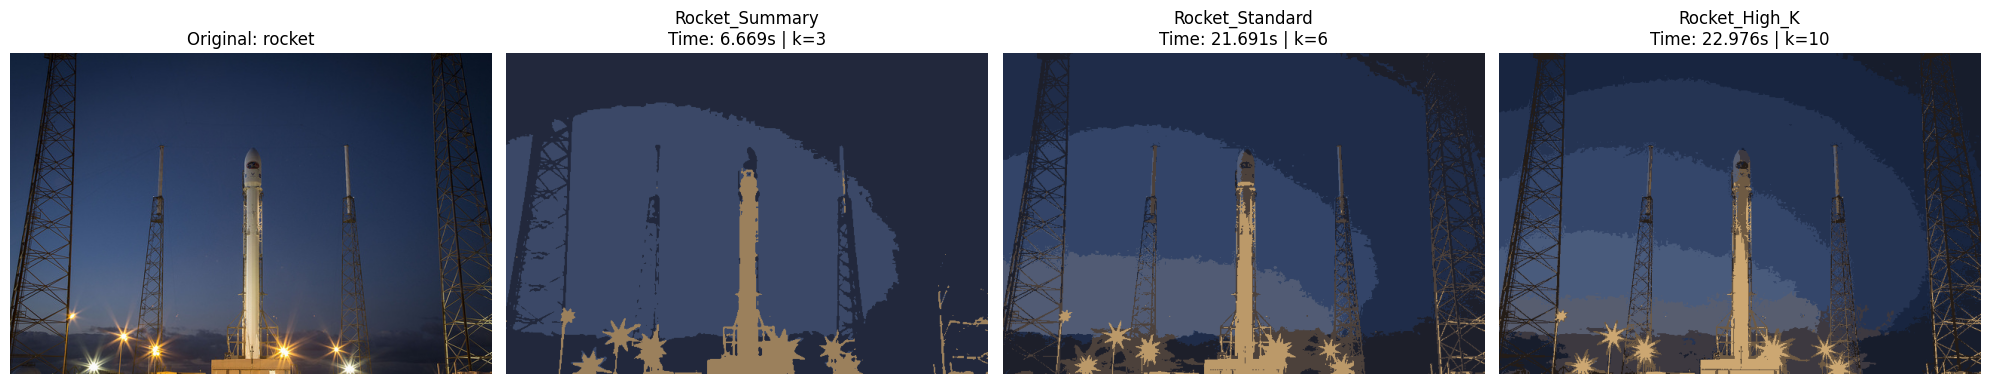

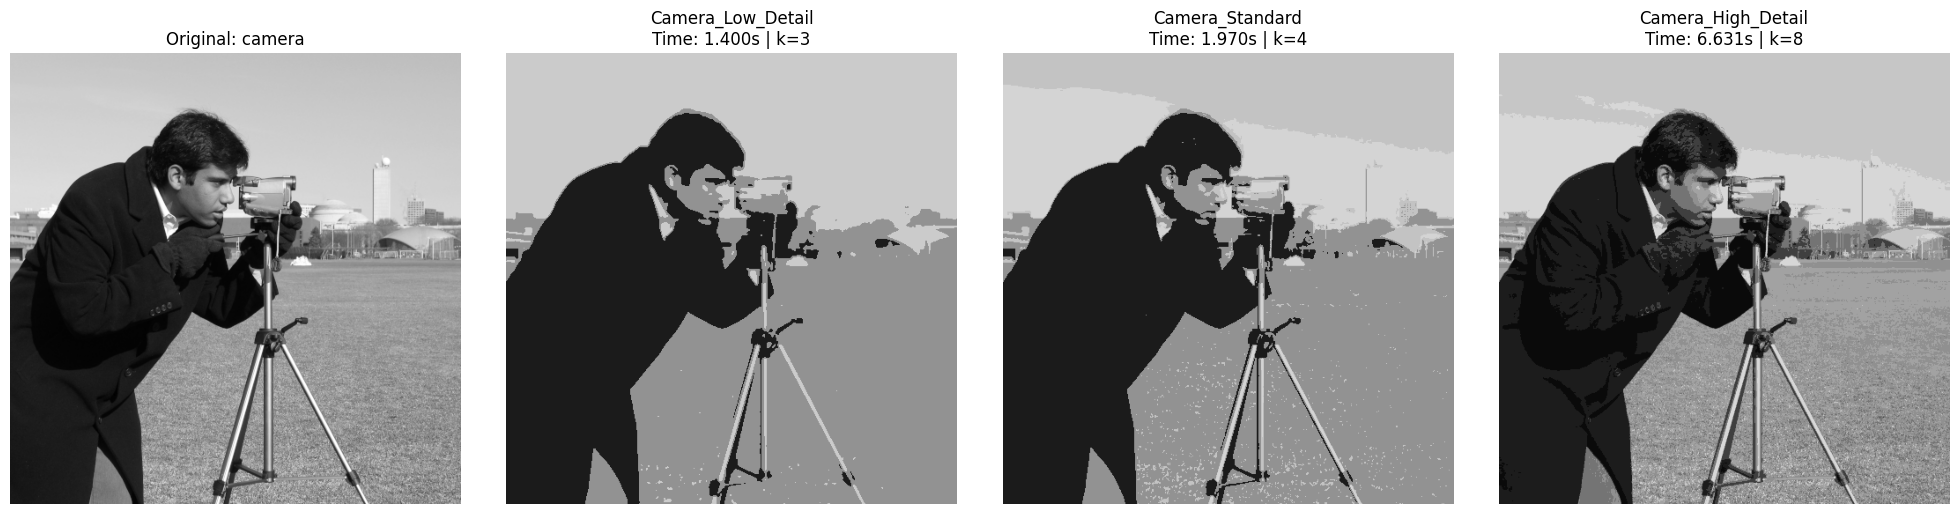

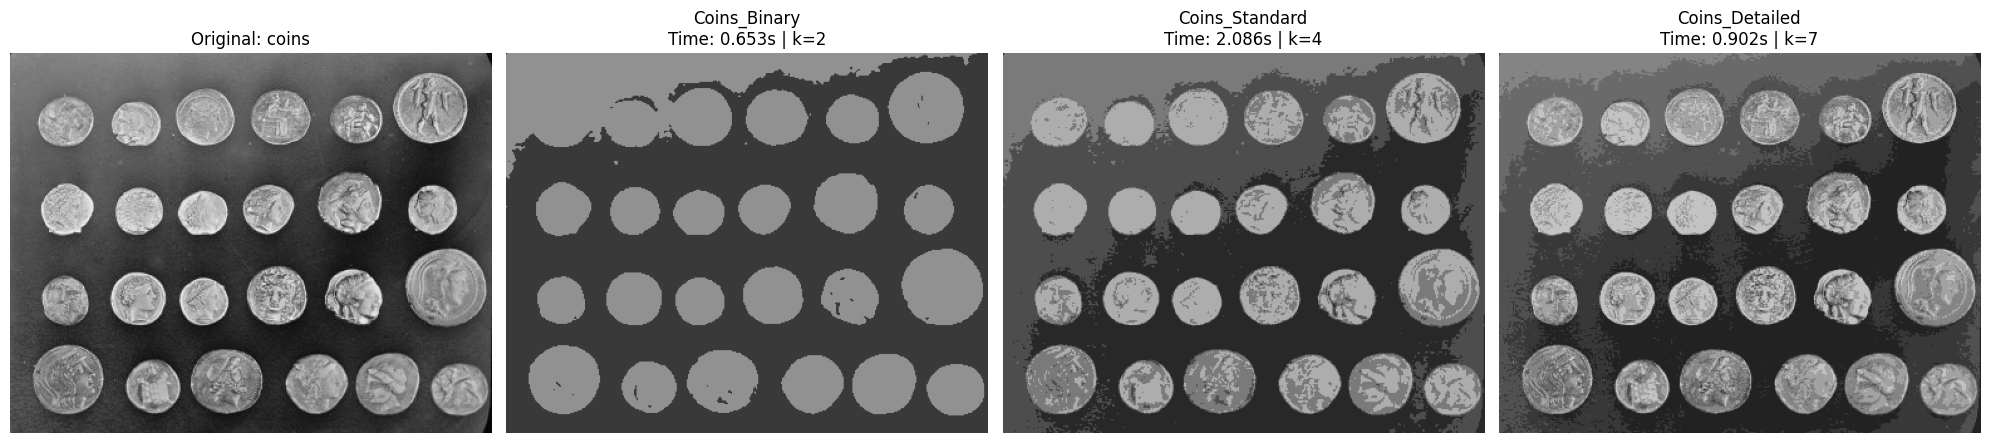

In [1]:
"""QBCA image segmentation analysis."""

import json
import time
import matplotlib.pyplot as plt
from skimage import color, data
from scipy.ndimage import gaussian_filter
from qbca import QBCA

# Load the comprehensive configuration
with open('config/config_segmentation.json', 'r') as f:
    config_data = json.load(f)

# Group experiments by image for a clear visual comparison
from collections import defaultdict
grouped = defaultdict(list)
for exp in config_data['experiments']:
    grouped[exp['image_func']].append(exp)

for img_func_name, exps in grouped.items():
    # Dynamic fetching from skimage.data
    img_func = getattr(data, img_func_name)
    img = img_func()

    # Handle Grayscale: Paper assumes 3-attribute points (L, a, b)
    if img.ndim == 2:
        img = color.gray2rgb(img)

    n_cols = len(exps) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

    # Show Original
    axes[0].imshow(img)
    axes[0].set_title(f"Original: {img_func_name}")
    axes[0].axis('off')

    for idx, cfg in enumerate(exps):
        # 1. Preprocessing: Gaussian smoothing (cite: 550, 553)
        img_smoothed = gaussian_filter(img, sigma=(cfg['sigma'], cfg['sigma'], 0))

        # 2. Feature Extraction: Lab space (cite: 547, 548)
        img_lab = color.rgb2lab(img_smoothed)
        pixel_data = img_lab.reshape((-1, 3))

        # 3. QBCA Run (cite: 396, 400)
        model = QBCA(k=cfg['k'], threshold=cfg['epsilon'], max_iter=cfg['max_iter'])
        start_time = time.time()
        labels, centers, _ = model.fit(pixel_data)
        elapsed = time.time() - start_time

        # 4. Reconstruction: Point assignment (cite: 56, 381)
        segmented_lab = centers[labels].reshape(img_lab.shape)
        segmented_rgb = color.lab2rgb(segmented_lab)

        # Plotting results
        ax = axes[idx + 1]
        ax.imshow(segmented_rgb)
        ax.set_title(f"{cfg['name']}\nTime: {elapsed:.3f}s | k={cfg['k']}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()